<a href="https://colab.research.google.com/github/fboldt/aulasann/blob/main/aula13a_autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Autoencoders

In [33]:
import torch
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print('Using device:', device)
print()

Using device: cuda



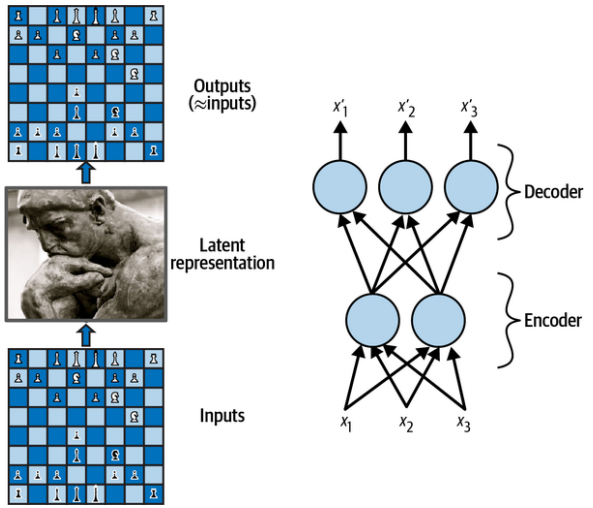

In [34]:
import torch.nn as nn

torch.manual_seed(42)
encoder = nn.Linear(3,2)
decoder = nn.Linear(2,3)
autoencoder = nn.Sequential(encoder,decoder).to(device)
autoencoder

Sequential(
  (0): Linear(in_features=3, out_features=2, bias=True)
  (1): Linear(in_features=2, out_features=3, bias=True)
)

In [35]:
import numpy as np
from scipy.spatial.transform import Rotation

def generate_data(m, seed=42):
    X = np.zeros((m,3))
    rng = np.random.default_rng(seed)
    angles = (rng.random(m) ** 3 + 0.5) * 2 * np.pi
    X[:,0], X[:,1] = np.cos(angles), np.sin(angles) * 0.5
    X += 0.28 * rng.standard_normal((m,3))
    X = Rotation.from_rotvec([np.pi/29, -np.pi/20, np.pi/4]).apply(X)
    X += [0.2, 0, 0.2]
    return torch.from_numpy(X.astype(np.float32))

In [36]:
from torch.utils.data import DataLoader, TensorDataset

X_train = generate_data(60, seed=42)
train_set = TensorDataset(X_train, X_train)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)

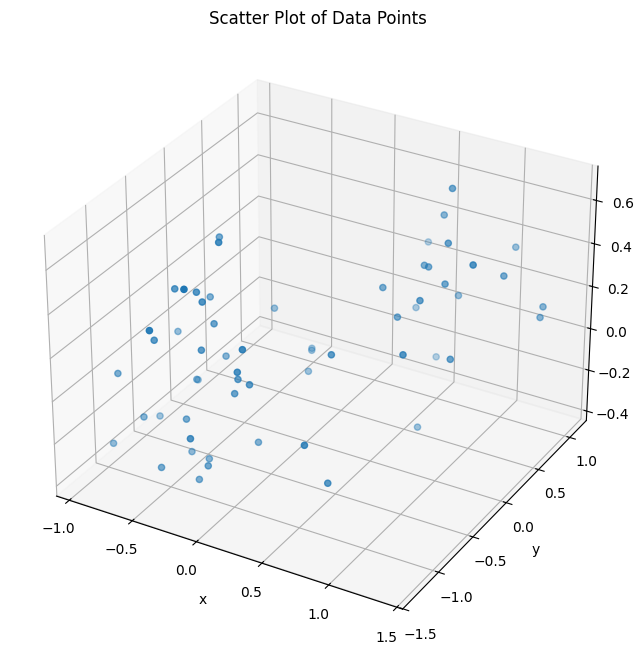

In [37]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

X_train_np = X_train.cpu().numpy()

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_train_np[:,0], X_train_np[:,1], X_train_np[:,2])

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Scatter Plot of Data Points')

plt.show()

In [38]:
X_valid = generate_data(500, seed=43)
valid_set = TensorDataset(X_valid, X_valid)
valid_loader = DataLoader(valid_set, batch_size=32)

In [9]:
!pip install torchmetrics -qq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 29.8 MB/s eta 0:00:00


In [41]:
import torchmetrics

def evaluate_model(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            if isinstance(y_pred, tuple):
                y_pred = y_pred.output
            metric.update(y_pred, y_batch)
    return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader, valid_loader,
          n_epochs, patience=2, factor=0.5, epoch_callback=None):
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,
                                                           mode="max",
                                                           factor=factor,
                                                           patience=patience)
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        if epoch_callback is not None:
            epoch_callback(model, epoch)
        for index, (X_batch, y_batch) in enumerate(train_loader):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()
            if isinstance(y_pred, tuple):
                y_pred = y_pred.output
            metric.update(y_pred, y_batch)
            train_metric = metric.compute()
            print(f"\rBatch: {index+1}/{len(train_loader)}, ", end="")
            print(f"Loss: {total_loss/(index+1):.4f}, Metric: {train_metric:.3f}", end="")
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(train_metric)
        valid_metric = evaluate_model(model, valid_loader, metric)
        history["valid_metrics"].append(valid_metric)
        scheduler.step(valid_metric)
        print(f"\rEpoch: {epoch+1}/{n_epochs}, Train Loss: {history['train_losses'][-1]:.4f}, ", end="")
        print(f"Train Metric: {history['train_metrics'][-1]:.3f}, ", end="")
        print(f"Valid Metric: {history['valid_metrics'][-1]:.3f}")
    return history


In [42]:
import torchmetrics

torch.manual_seed(42)
optimizer = torch.optim.NAdam(autoencoder.parameters(), lr=0.2)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
history = train(autoencoder, optimizer, mse, rmse, train_loader, valid_loader, n_epochs=20)

Epoch: 1/20, Train Loss: 0.1075, Train Metric: 0.319, Valid Metric: 0.253
Epoch: 2/20, Train Loss: 0.0606, Train Metric: 0.247, Valid Metric: 0.203
Epoch: 3/20, Train Loss: 0.0328, Train Metric: 0.179, Valid Metric: 0.201
Epoch: 4/20, Train Loss: 0.0311, Train Metric: 0.176, Valid Metric: 0.214
Epoch: 5/20, Train Loss: 0.0333, Train Metric: 0.183, Valid Metric: 0.182
Epoch: 6/20, Train Loss: 0.0272, Train Metric: 0.165, Valid Metric: 0.184
Epoch: 7/20, Train Loss: 0.0281, Train Metric: 0.167, Valid Metric: 0.176
Epoch: 8/20, Train Loss: 0.0241, Train Metric: 0.154, Valid Metric: 0.171
Epoch: 9/20, Train Loss: 0.0245, Train Metric: 0.158, Valid Metric: 0.172
Epoch: 10/20, Train Loss: 0.0228, Train Metric: 0.152, Valid Metric: 0.170
Epoch: 11/20, Train Loss: 0.0231, Train Metric: 0.153, Valid Metric: 0.169
Epoch: 12/20, Train Loss: 0.0232, Train Metric: 0.152, Valid Metric: 0.169
Epoch: 13/20, Train Loss: 0.0234, Train Metric: 0.153, Valid Metric: 0.169
Epoch: 14/20, Train Loss: 0.0224, 

In [43]:
codings = encoder(X_train.to(device))
codings.shape

torch.Size([60, 2])

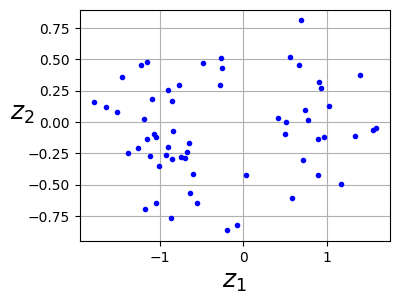

In [44]:
fig = plt.figure(figsize=(4,3))
codings_np = codings.cpu().detach().numpy()
plt.plot(codings_np[:,0], codings_np[:,1], "b.")
plt.xlabel("$z_1$", fontsize=18)
plt.ylabel("$z_2$", fontsize=18, rotation=0)
plt.grid((True))
plt.show()

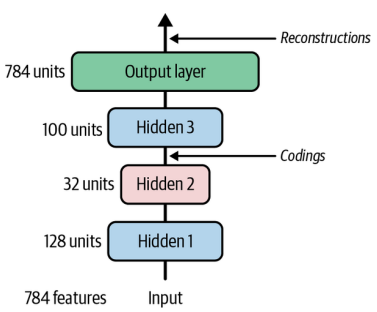

In [45]:
torch.manual_seed(42)

stacked_encoder = nn.Sequential(
    nn.Flatten(),
    nn.Linear(1 * 28 * 28, 128), nn.ReLU(),
    nn.Linear(128, 32), nn.ReLU(),
)
stacked_decoder = nn.Sequential(
    nn.Linear(32, 128), nn.ReLU(),
    nn.Linear(128, 1 * 28 * 28), nn.Sigmoid(),
    nn.Unflatten(1, unflattened_size=(1, 28, 28))
)
stacked_ae = nn.Sequential(stacked_encoder, stacked_decoder).to(device)
stacked_ae

Sequential(
  (0): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=32, bias=True)
    (4): ReLU()
  )
  (1): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=784, bias=True)
    (3): Sigmoid()
    (4): Unflatten(dim=1, unflattened_size=(1, 28, 28))
  )
)

In [46]:
import torchvision
import torchvision.transforms.v2 as T

toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=True, download=True, transform=toTensor
)
test_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=toTensor
)
torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000])

In [47]:
from torch.utils.data import Dataset

class AutoencoderDataset(Dataset):
    def __init__(self, base_dataset):
        self.base_dataset = base_dataset
    def __len__(self):
      return len(self.base_dataset)
    def __getitem__(self, idx):
      x, _ = self.base_dataset[idx]
      return x, x

train_loader = DataLoader(AutoencoderDataset(train_data), batch_size=32, shuffle=True)
valid_loader = DataLoader(AutoencoderDataset(valid_data), batch_size=32)
test_loader = DataLoader(AutoencoderDataset(test_data), batch_size=32)

In [48]:
optimizer = torch.optim.NAdam(stacked_ae.parameters(), lr=0.01)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
history = train(stacked_ae, optimizer, mse, rmse, train_loader, valid_loader, n_epochs=10)

Epoch: 1/10, Train Loss: 0.0253, Train Metric: 0.159, Valid Metric: 0.144
Epoch: 2/10, Train Loss: 0.0196, Train Metric: 0.140, Valid Metric: 0.142
Epoch: 3/10, Train Loss: 0.0185, Train Metric: 0.136, Valid Metric: 0.134
Epoch: 4/10, Train Loss: 0.0179, Train Metric: 0.134, Valid Metric: 0.133
Epoch: 5/10, Train Loss: 0.0159, Train Metric: 0.126, Valid Metric: 0.126
Epoch: 6/10, Train Loss: 0.0155, Train Metric: 0.125, Valid Metric: 0.126
Epoch: 7/10, Train Loss: 0.0152, Train Metric: 0.123, Valid Metric: 0.124
Epoch: 8/10, Train Loss: 0.0144, Train Metric: 0.120, Valid Metric: 0.121
Epoch: 9/10, Train Loss: 0.0142, Train Metric: 0.119, Valid Metric: 0.121
Epoch: 10/10, Train Loss: 0.0141, Train Metric: 0.119, Valid Metric: 0.120


In [49]:
def plot_image(image):
    plt.imshow(image.permute(1,2,0).cpu(), cmap="binary")
    plt.axis("off")

def plot_reconstructions(model, images, n_images=5):
    images = images[:n_images]
    with torch.no_grad():
        y_pred = model(images.to(device))
    if isinstance(y_pred, tuple):
        y_pred = y_pred.output
    fig = plt.figure(figsize=(len(images)*1.5, 3))
    for idx in range(len(images)):
        plt.subplot(2, len(images), 1 + idx)
        plot_image(images[idx])
        plt.subplot(2, len(images), len(images) + 1 + idx)
        plot_image(y_pred[idx])

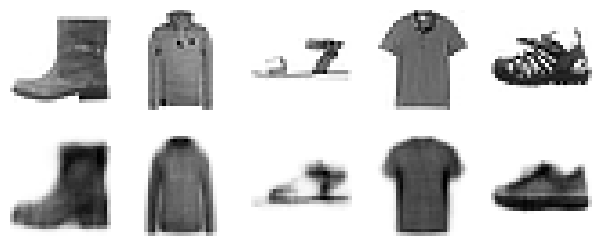

In [52]:
X_train = torch.stack([x for x, _ in train_data])
plot_reconstructions(stacked_ae, X_train)

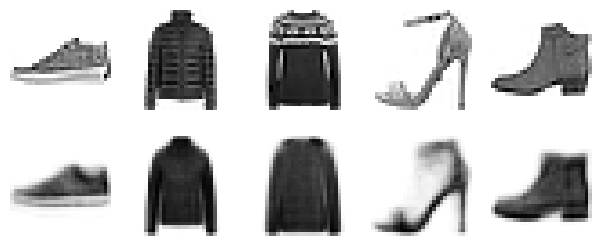

In [50]:
X_valid = torch.stack([x for x, _ in valid_data])
plot_reconstructions(stacked_ae, X_valid)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 495kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.55MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.5MB/s]


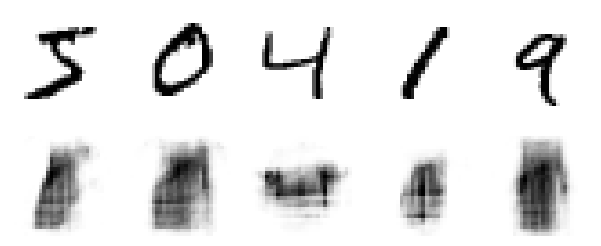

In [51]:
torch.manual_seed(42)
mnist_data = torchvision.datasets.MNIST(
    root="datasets", train=True, download=True, transform=toTensor
)
mnist_images = torch.stack([mnist_data[i][0] for i in range(X_valid.size(0))])
plot_reconstructions(stacked_ae, images=mnist_images)
plt.show()

In [53]:
images = mnist_images.to(device)
with torch.no_grad():
    y_pred = stacked_ae(images)
    recon_loss = torch.nn.functional.mse_loss(y_pred, images)

recon_loss

tensor(0.0599, device='cuda:0')

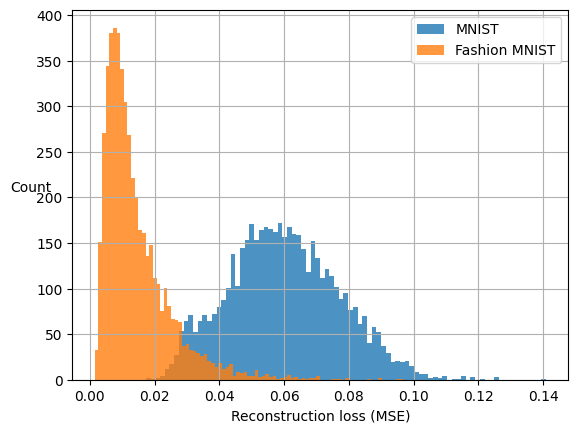

In [54]:
import torch.nn.functional as F

def compute_reconstruction_losses(X, device):
    X = X.to(device)
    with torch.no_grad():
        y_pred = stacked_ae(X)
        return F.mse_loss(y_pred, X, reduction="none").view(X.size(0), -1).mean(dim=1).cpu()

recon_losses_mnist = compute_reconstruction_losses(mnist_images, device)
recon_losses_fashion_mnist = compute_reconstruction_losses(X_valid, device)

plt.hist(recon_losses_mnist, bins=85, alpha=0.8, label="MNIST")
plt.hist(recon_losses_fashion_mnist, bins=85, alpha=0.8, label="Fashion MNIST")
plt.xlabel("Reconstruction loss (MSE)")
plt.ylabel("Count", rotation=0)
plt.legend()
plt.grid()
plt.show()

In [55]:
from sklearn.manifold import TSNE

with torch.no_grad():
    X_valid_compressed = stacked_encoder(X_valid.to(device))

tsne = TSNE(init="pca", learning_rate="auto", random_state=42)
X_valid_2D = tsne.fit_transform(X_valid_compressed.cpu())

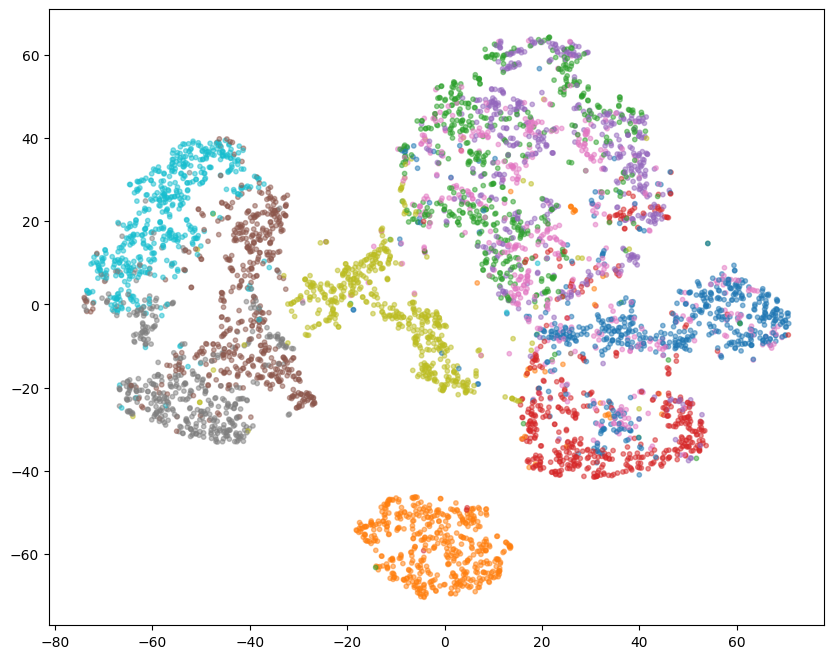

In [57]:
y_valid = torch.tensor([y for _, y in valid_data])

plt.figure(figsize=(10, 8))
plt.scatter(X_valid_2D[:, 0], X_valid_2D[:, 1], c=y_valid, s=10, alpha=0.5, cmap="tab10")
plt.show()

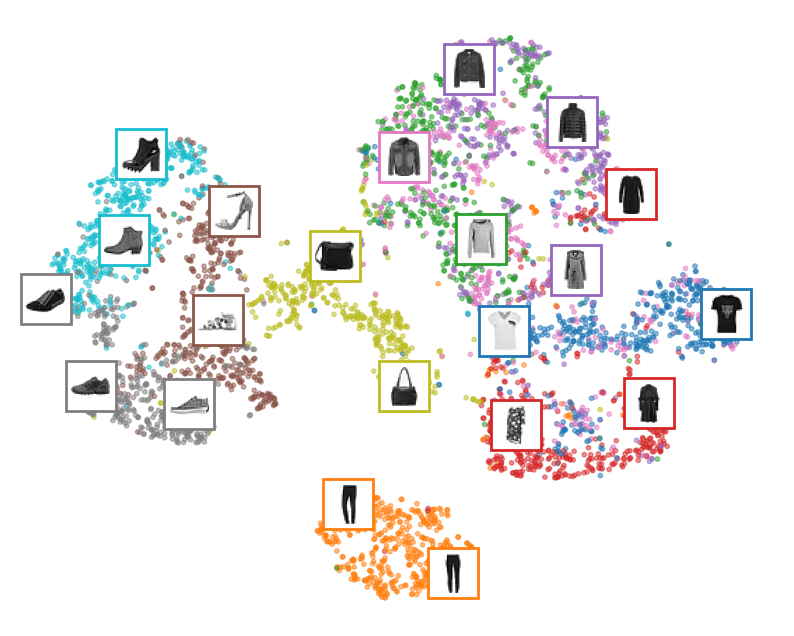

In [59]:
import matplotlib as mpl

plt.figure(figsize=(10, 8))
cmap = plt.cm.tab10
Z = X_valid_2D
Z = (Z - Z.min()) / (Z.max() - Z.min())
plt.scatter(Z[:, 0], Z[:, 1], c=y_valid, s=10, alpha=0.5, cmap=cmap)
image_positions = np.array([[1., 1,]])
for index, position in enumerate(Z):
    dist = ((position - image_positions) ** 2).sum(axis=1)
    if dist.min() > 0.02:
        image_positions = np.r_[image_positions, [position]]
        imagebox = mpl.offsetbox.AnnotationBbox(
            mpl.offsetbox.OffsetImage(X_valid[index].squeeze(dim=0), cmap="binary"),
            position, bboxprops={"edgecolor": cmap(y_valid[index]), "lw": 2})
        plt.gca().add_artist(imagebox)
plt.axis("off")
plt.show()

In [60]:
import torch.nn.functional as F

class TiedAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Linear(1 * 28 * 28, 128)
        self.enc2 = nn.Linear(128, 32)
        self.dec1_bias = nn.Parameter(torch.zeros(128))
        self.dec2_bias = nn.Parameter(torch.zeros(1 * 28 * 28))

    def encode(self, X):
        Z = X.view(-1, 1 * 28 * 28)
        Z = F.relu(self.enc1(Z))
        Z = F.relu(self.enc2(Z))
        return Z

    def decode(self, X):
        Z = F.relu(F.linear(X, self.enc2.weight.t(), self.dec1_bias))
        Z = F.sigmoid(F.linear(Z, self.enc1.weight.T, self.dec2_bias))
        return Z.view(-1, 1, 28, 28)

    def forward(self, X):
        return self.decode(self.encode(X))

tied_ae = TiedAutoencoder().to(device)
optimizer = torch.optim.NAdam(tied_ae.parameters(), lr=0.01)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
history = train(tied_ae, optimizer, mse, rmse, train_loader, valid_loader, n_epochs=10)

Epoch: 1/10, Train Loss: 0.0229, Train Metric: 0.151, Valid Metric: 0.137
Epoch: 2/10, Train Loss: 0.0174, Train Metric: 0.132, Valid Metric: 0.132
Epoch: 3/10, Train Loss: 0.0166, Train Metric: 0.129, Valid Metric: 0.131
Epoch: 4/10, Train Loss: 0.0162, Train Metric: 0.127, Valid Metric: 0.126
Epoch: 5/10, Train Loss: 0.0140, Train Metric: 0.119, Valid Metric: 0.121
Epoch: 6/10, Train Loss: 0.0137, Train Metric: 0.117, Valid Metric: 0.118
Epoch: 7/10, Train Loss: 0.0135, Train Metric: 0.116, Valid Metric: 0.118
Epoch: 8/10, Train Loss: 0.0127, Train Metric: 0.113, Valid Metric: 0.114
Epoch: 9/10, Train Loss: 0.0125, Train Metric: 0.112, Valid Metric: 0.113
Epoch: 10/10, Train Loss: 0.0124, Train Metric: 0.112, Valid Metric: 0.112


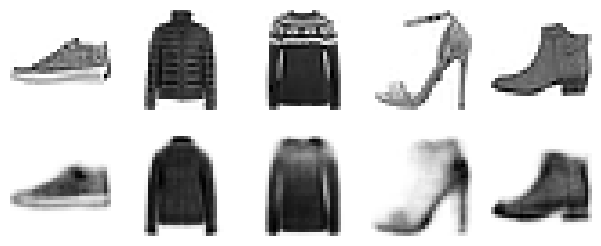

In [61]:
plot_reconstructions(tied_ae, X_valid)
plt.show()

In [63]:
torch.manual_seed(42)

conv_encoder = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding="same"), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Conv2d(16, 32, kernel_size=3, padding="same"), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Conv2d(32, 64, kernel_size=3, padding="same"), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Conv2d(64, 32, kernel_size=3, padding="same"), nn.ReLU(),
    nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten()
)

conv_decoder = nn.Sequential(
    nn.Linear(32, 16 * 3 * 3),
    nn.Unflatten(1, unflattened_size=(16, 3, 3)),
    nn.ConvTranspose2d(16, 32, kernel_size=3, stride=2), nn.ReLU(),
    nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
    nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1), nn.Sigmoid()
)

conv_ae = nn.Sequential(conv_encoder, conv_decoder).to(device)

optimizer = torch.optim.NAdam(conv_ae.parameters(), lr=0.005)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
history = train(conv_ae, optimizer, mse, rmse, train_loader, valid_loader, n_epochs=10)

Epoch: 1/10, Train Loss: 0.0287, Train Metric: 0.169, Valid Metric: 0.141
Epoch: 2/10, Train Loss: 0.0169, Train Metric: 0.130, Valid Metric: 0.131
Epoch: 3/10, Train Loss: 0.0148, Train Metric: 0.122, Valid Metric: 0.119
Epoch: 4/10, Train Loss: 0.0137, Train Metric: 0.117, Valid Metric: 0.115
Epoch: 5/10, Train Loss: 0.0124, Train Metric: 0.111, Valid Metric: 0.111
Epoch: 6/10, Train Loss: 0.0121, Train Metric: 0.110, Valid Metric: 0.111
Epoch: 7/10, Train Loss: 0.0118, Train Metric: 0.109, Valid Metric: 0.109
Epoch: 8/10, Train Loss: 0.0114, Train Metric: 0.107, Valid Metric: 0.108
Epoch: 9/10, Train Loss: 0.0113, Train Metric: 0.106, Valid Metric: 0.107
Epoch: 10/10, Train Loss: 0.0112, Train Metric: 0.106, Valid Metric: 0.107


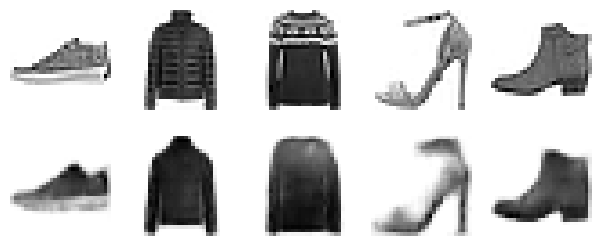

In [64]:
plot_reconstructions(conv_ae, X_valid)
plt.show()

In [65]:
class RecurrentAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder_lstm = nn.LSTM(input_size=28, hidden_size=128,
                                    num_layers=2, batch_first=True)
        self.encoder_proj = nn.Linear(128, 32)  # Compress to latent vector
        self.decoder_lstm = nn.LSTM(input_size=32, hidden_size=128,
                                    batch_first=True)
        self.decoder_proj = nn.Linear(128, 28)

    def encode(self, X):  # X shape: [B, 1, 28, 28]
        Z = X.squeeze(dim=1)  # Z shape: [B, 28, 28]
        _, (h_n, _) = self.encoder_lstm(Z)  # h_n shape: [2, B, 100]
        Z = h_n[-1]  # get the hidden state of the last layer: [B, 100]
        return self.encoder_proj(Z)  # [B, 30]

    def decode(self, X):
        Z = X.unsqueeze(dim=1).repeat(1, 28, 1)  # [B, 28, 32]
        Z, _ = self.decoder_lstm(Z)  # [B, 28, 100]
        return F.sigmoid(self.decoder_proj(Z).unsqueeze(dim=1)) # [B, 1, 28, 28]

    def forward(self, X):
        return self.decode(self.encode(X))

torch.manual_seed(42)
recurrent_ae = RecurrentAutoencoder().to(device)
optimizer = torch.optim.NAdam(recurrent_ae.parameters(), lr=1e-3)
history = train(recurrent_ae, optimizer, mse, rmse, train_loader, valid_loader,
                n_epochs=10)

Epoch: 1/10, Train Loss: 0.0526, Train Metric: 0.229, Valid Metric: 0.181
Epoch: 2/10, Train Loss: 0.0259, Train Metric: 0.161, Valid Metric: 0.152
Epoch: 3/10, Train Loss: 0.0209, Train Metric: 0.145, Valid Metric: 0.139
Epoch: 4/10, Train Loss: 0.0178, Train Metric: 0.134, Valid Metric: 0.127
Epoch: 5/10, Train Loss: 0.0151, Train Metric: 0.123, Valid Metric: 0.123
Epoch: 6/10, Train Loss: 0.0141, Train Metric: 0.119, Valid Metric: 0.117
Epoch: 7/10, Train Loss: 0.0133, Train Metric: 0.115, Valid Metric: 0.114
Epoch: 8/10, Train Loss: 0.0125, Train Metric: 0.112, Valid Metric: 0.112
Epoch: 9/10, Train Loss: 0.0122, Train Metric: 0.110, Valid Metric: 0.110
Epoch: 10/10, Train Loss: 0.0118, Train Metric: 0.109, Valid Metric: 0.109


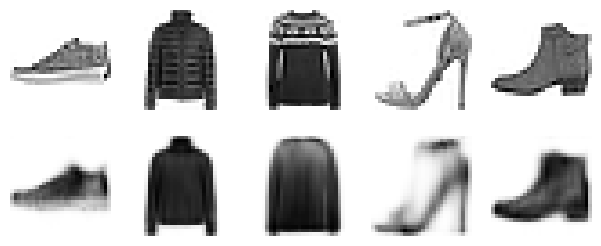

In [66]:
plot_reconstructions(recurrent_ae, X_valid)
plt.show()

In [67]:
torch.manual_seed(42)

dropout_encoder = nn.Sequential(
    nn.Flatten(),
    nn.Dropout(0.5),
    nn.Linear(1 * 28 * 28, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
)
dropout_decoder = nn.Sequential(
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 1 * 28 * 28), nn.Sigmoid(),
    nn.Unflatten(dim=1, unflattened_size=(1, 28, 28))
)
dropout_ae = nn.Sequential(dropout_encoder, dropout_decoder).to(device)

optimizer = torch.optim.NAdam(dropout_ae.parameters(), lr=0.01)
history = train(dropout_ae, optimizer, mse, rmse, train_loader, valid_loader,
                n_epochs=10)

Epoch: 1/10, Train Loss: 0.0279, Train Metric: 0.167, Valid Metric: 0.148
Epoch: 2/10, Train Loss: 0.0230, Train Metric: 0.152, Valid Metric: 0.146
Epoch: 3/10, Train Loss: 0.0225, Train Metric: 0.150, Valid Metric: 0.144
Epoch: 4/10, Train Loss: 0.0224, Train Metric: 0.150, Valid Metric: 0.144
Epoch: 5/10, Train Loss: 0.0205, Train Metric: 0.143, Valid Metric: 0.138
Epoch: 6/10, Train Loss: 0.0201, Train Metric: 0.142, Valid Metric: 0.137
Epoch: 7/10, Train Loss: 0.0199, Train Metric: 0.141, Valid Metric: 0.136
Epoch: 8/10, Train Loss: 0.0189, Train Metric: 0.138, Valid Metric: 0.132
Epoch: 9/10, Train Loss: 0.0187, Train Metric: 0.137, Valid Metric: 0.132
Epoch: 10/10, Train Loss: 0.0186, Train Metric: 0.136, Valid Metric: 0.131


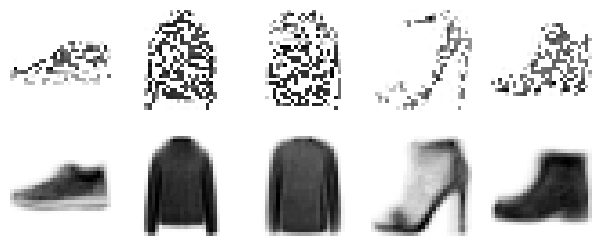

In [74]:
torch.manual_seed(42)
dropout = nn.Dropout(0.5)
plot_reconstructions(dropout_ae, dropout(X_valid))
plt.show()

In [69]:
class GaussianNoise(nn.Module):
    def __init__(self, std):
      super().__init__()
      self.std = std

    def forward(self, X):
      if self.training:
        noise = torch.randn_like(X) * self.std
        return X + noise
      return X

In [70]:
torch.manual_seed(42)

noise_encoder = nn.Sequential(
    nn.Flatten(),
    GaussianNoise(0.5),
    nn.Linear(1 * 28 * 28, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
)
noise_decoder = nn.Sequential(
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 1 * 28 * 28), nn.Sigmoid(),
    nn.Unflatten(dim=1, unflattened_size=(1, 28, 28))
)
noise_ae = nn.Sequential(noise_encoder, noise_decoder).to(device)

optimizer = torch.optim.NAdam(noise_ae.parameters(), lr=0.01)
history = train(noise_ae, optimizer, mse, rmse, train_loader, valid_loader,
                n_epochs=10)

Epoch: 1/10, Train Loss: 0.0290, Train Metric: 0.170, Valid Metric: 0.150
Epoch: 2/10, Train Loss: 0.0239, Train Metric: 0.155, Valid Metric: 0.149
Epoch: 3/10, Train Loss: 0.0235, Train Metric: 0.153, Valid Metric: 0.150
Epoch: 4/10, Train Loss: 0.0233, Train Metric: 0.153, Valid Metric: 0.146
Epoch: 5/10, Train Loss: 0.0214, Train Metric: 0.146, Valid Metric: 0.138
Epoch: 6/10, Train Loss: 0.0209, Train Metric: 0.145, Valid Metric: 0.138
Epoch: 7/10, Train Loss: 0.0208, Train Metric: 0.144, Valid Metric: 0.137
Epoch: 8/10, Train Loss: 0.0198, Train Metric: 0.141, Valid Metric: 0.133
Epoch: 9/10, Train Loss: 0.0196, Train Metric: 0.140, Valid Metric: 0.132
Epoch: 10/10, Train Loss: 0.0194, Train Metric: 0.139, Valid Metric: 0.132


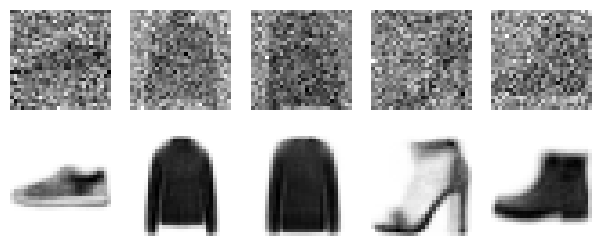

In [72]:
torch.manual_seed(42)
noise = GaussianNoise(0.5)
plot_reconstructions(noise_ae, noise(X_valid))
plt.show()